In [107]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns

In [108]:
model_traces = {}

later_drops = pd.read_csv("later_drops.csv")
batches = sorted(later_drops['Batch_ID'].unique())

for current_batch in batches:
    file_path = f"v1_traces/trace_batch_{current_batch}.nc"
    if os.path.exists(file_path):
        model_traces[current_batch] = az.from_netcdf(file_path)
        print(f"Loaded Batch {current_batch} successfully.")
    else:
        print(f"File not found: {file_path}")

# Complete integer range — carry-forward fills any gaps (e.g. batch 6)
plot_batches = list(range(min(batches), max(batches) + 1))
nearest_trace_batch = {b: max(t for t in batches if t <= b) for b in plot_batches}

missing = [b for b in plot_batches if b not in batches]
print(f"\nplot_batches: {len(plot_batches)} total | carried forward: {missing}")


Loaded Batch 3 successfully.
Loaded Batch 4 successfully.
Loaded Batch 5 successfully.
Loaded Batch 7 successfully.
Loaded Batch 8 successfully.
Loaded Batch 9 successfully.
Loaded Batch 10 successfully.
Loaded Batch 11 successfully.
Loaded Batch 12 successfully.
Loaded Batch 13 successfully.
Loaded Batch 14 successfully.
Loaded Batch 15 successfully.
Loaded Batch 16 successfully.
Loaded Batch 17 successfully.
Loaded Batch 18 successfully.
Loaded Batch 19 successfully.
Loaded Batch 20 successfully.
Loaded Batch 21 successfully.
Loaded Batch 22 successfully.
Loaded Batch 23 successfully.
Loaded Batch 24 successfully.
Loaded Batch 25 successfully.
Loaded Batch 26 successfully.
Loaded Batch 27 successfully.

plot_batches: 25 total | carried forward: [6]


In [109]:
# Build the same race index used during training
first_drop = pd.read_csv("first_drop.csv")

all_races = np.unique(np.concatenate((first_drop['Race'], later_drops['Race'])))
n_races   = len(all_races)

race_cat_type = pd.CategoricalDtype(categories=all_races, ordered=True)
first_drop['race_idx']  = first_drop['Race'].astype(race_cat_type).cat.codes
later_drops['race_idx'] = later_drops['Race'].astype(race_cat_type).cat.codes

baseline_array    = first_drop.sort_values('race_idx')['Dem_Prop_Before_11_08'].values
race_denominators = later_drops.groupby('race_idx')['Total Votes Cast'].max().values

print("Races:        ", all_races)
print("Baselines:    ", baseline_array.round(4))
print("Denominators: ", race_denominators)

Races:         ['AD-58' 'CD-13' 'CD-21' 'CD-22' 'CD-40' 'CD-41' 'CD-45' 'CD-47' 'CD-49'
 'CD-9' 'SD-19' 'SD-37' 'SD-5']
Baselines:     [0.4871 0.4862 0.5057 0.4495 0.436  0.4849 0.4809 0.4989 0.5112 0.5069
 0.4668 0.4828 0.5016]
Denominators:  [155988 210921 195531 167507 383635 354445 315875 353275 378347 251357
 383030 458615 358804]


In [110]:
# Diagnostic: check which races have votes_remaining = 0 at each batch
print("Races with votes_remaining = 0 (not yet seen in later_drops):\n")
for i, current_batch in enumerate(batches):
    current_data = (later_drops[later_drops['Batch_ID'] <= current_batch]
                    .sort_values('Batch_ID')
                    .drop_duplicates(subset=['race_idx'], keep='last'))
    
    votes_remaining = np.zeros(n_races)
    ridx = current_data['race_idx'].values
    votes_remaining[ridx] = current_data['Votes_Remaining'].values
    
    missing = [all_races[j] for j in range(n_races) if votes_remaining[j] == 0]
    if missing:
        print(f"  Batch {current_batch}: {missing}")


Races with votes_remaining = 0 (not yet seen in later_drops):

  Batch 3: ['CD-41']
  Batch 27: ['AD-58', 'CD-13', 'CD-21', 'CD-22', 'CD-40', 'CD-41', 'CD-45', 'CD-47', 'CD-49', 'CD-9', 'SD-19', 'SD-37', 'SD-5']


In [111]:
final_tally = later_drops[later_drops["Batch_ID"] == 27].set_index("Race").sort_values("Race")
official_dem_prop = final_tally["D"].divide(final_tally["Total Votes Cast"])
official_dem_prop

Race
AD-58    0.498090
CD-13    0.500443
CD-21    0.525738
CD-22    0.465789
CD-40    0.447397
CD-41    0.483090
CD-45    0.501034
CD-47    0.514390
CD-49    0.521735
CD-9     0.517921
SD-19    0.452421
SD-37    0.493377
SD-5     0.528612
dtype: float64

In [112]:
# Stage 1: Extract 1000 evenly-spaced posterior draws per batch
extracted_posteriors = {}

for current_batch, trace in model_traces.items():
    s_r_raw       = trace.posterior["s_r"].values               # (chains, draws, n_races)
    s_g_raw       = trace.posterior["s_g"].values               # (chains, draws)
    sig_batch_raw = trace.posterior["sigma_batch"].values        # (chains, draws)

    s_r_flat       = s_r_raw.reshape(-1, n_races)
    s_g_flat       = s_g_raw.flatten()
    sig_batch_flat = sig_batch_raw.flatten()

    step         = len(s_g_flat) // 1000
    s_r_1000     = s_r_flat[::step][:1000]
    s_g_1000     = s_g_flat[::step][:1000]
    sig_b_1000   = sig_batch_flat[::step][:1000]

    extracted_posteriors[current_batch] = {
        "expected_b":  s_r_1000 + s_g_1000[:, np.newaxis] + baseline_array,  # (1000, n_races)
        "sigma_batch": sig_b_1000                                               # (1000,)
    }

print("Stage 1 complete: posteriors extracted.")

Stage 1 complete: posteriors extracted.


In [113]:
# Stage 2: For each batch, simulate Dem proportions for every future batch
rng_normal = np.random.default_rng(seed=42)
simulated_future_batches = {}

for i, current_batch in enumerate(batches):
    n_remaining = len(batches) - i - 1
    if n_remaining > 0:
        exp_b = extracted_posteriors[current_batch]["expected_b"]   # (1000, n_races)
        sig_b = extracted_posteriors[current_batch]["sigma_batch"]  # (1000,)
        simulated_future_batches[current_batch] = rng_normal.normal(
            loc   = exp_b[:, np.newaxis, :],           # (1000, 1, n_races)
            scale = sig_b[:, np.newaxis, np.newaxis],  # (1000, 1, 1)
            size  = (1000, n_remaining, n_races)
        )  # -> (1000, n_remaining, n_races)
    else:
        simulated_future_batches[current_batch] = None

print("Stage 2 complete: future batch proportions simulated.")

Stage 2 complete: future batch proportions simulated.


In [114]:
# Stage 3: Forward-sample final Dem vote counts using Dirichlet-weighted batch sizes
rng_dirichlet      = np.random.default_rng(seed=42)
final_outcomes_dict = {}
concentration_scale = 20.0

for i, current_batch in enumerate(batches):
    n_remaining = len(batches) - i - 1

    # Carry forward the latest known totals for each race
    current_data = (later_drops[later_drops['Batch_ID'] <= current_batch]
                    .sort_values('Batch_ID')
                    .drop_duplicates(subset=['race_idx'], keep='last'))

    current_dem_votes = np.zeros(n_races)
    votes_remaining   = np.zeros(n_races)
    ridx = current_data['race_idx'].values
    current_dem_votes[ridx] = current_data['D'].values
    votes_remaining[ridx]   = current_data['Votes_Remaining'].values

    unseen = votes_remaining == 0
    votes_remaining[unseen] = race_denominators[unseen]

    if n_remaining > 0:
        alphas = np.log(1 + 1 / np.arange(1, n_remaining + 1)) * concentration_scale
        dirichlet_draws = rng_dirichlet.dirichlet(alpha=alphas, size=(1000, n_races))
        dirichlet_draws = dirichlet_draws.transpose(0, 2, 1)

        sim_batch_sizes = dirichlet_draws * votes_remaining
        sim_dem_rates   = simulated_future_batches[current_batch]

        added_dem = (sim_batch_sizes * sim_dem_rates).sum(axis=1)
        final_outcomes_dict[current_batch] = current_dem_votes + added_dem
    else:
        final_outcomes_dict[current_batch] = np.tile(current_dem_votes, (1000, 1))

print("Stage 3 complete: final vote counts forward-sampled.")


def get_forward_samples(batch_id):
    """Returns (1000, n_races): forward-sampled final Dem proportions.
    If batch_id has no trace, carries forward the nearest earlier batch."""
    available = nearest_trace_batch[batch_id]
    return final_outcomes_dict[available] / race_denominators


Stage 3 complete: final vote counts forward-sampled.


## Predicted Final Dem Proportion Over Time

For each race: the 94% HDI and mean of the forward-sampled **final** Dem proportion at each batch. Orange line = official result; black dashed = first-drop baseline.

C:\Users\ricky\AppData\Local\Temp\ipykernel_15668\3638785128.py:9: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_bounds = az.hdi(samples, hdi_prob=0.90)


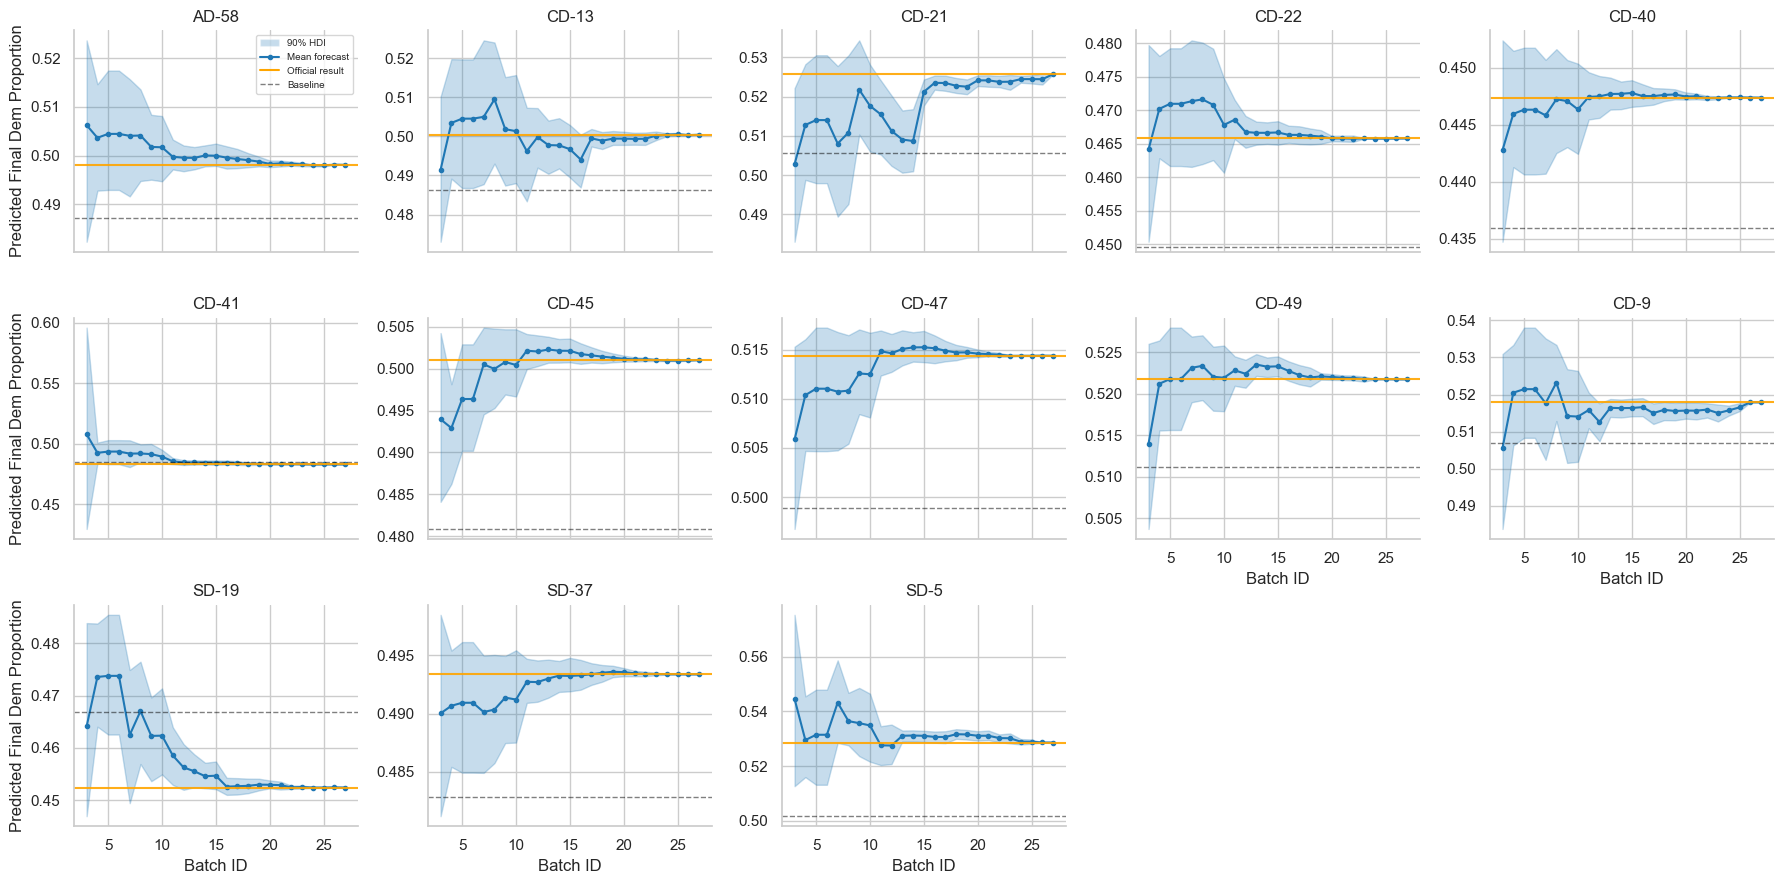

In [115]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fwd_records = []

for batch_id in plot_batches:
    samples    = get_forward_samples(batch_id)
    mean_val   = samples.mean(axis=0)
    hdi_bounds = az.hdi(samples, hdi_prob=0.90)

    for i, race in enumerate(all_races):
        fwd_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'mean':     mean_val[i],
            'lower_90': hdi_bounds[i, 0],
            'upper_90': hdi_bounds[i, 1],
            'baseline': baseline_array[i],
        })

fwd_df = pd.DataFrame(fwd_records).sort_values(['Race', 'Batch_ID'])


def plot_forward_evolution(data, **kwargs):
    ax   = plt.gca()
    race = data['Race'].iloc[0]
    ax.fill_between(data['Batch_ID'], data['lower_90'], data['upper_90'],
                    alpha=0.25, color='#1f77b4')
    ax.plot(data['Batch_ID'], data['mean'],
            color='#1f77b4', marker='o', markersize=3, lw=1.5)
    ax.axhline(data['baseline'].iloc[0],
               color='black', linestyle='--', lw=1, alpha=0.5)
    if race in official_dem_prop.index:
        ax.axhline(official_dem_prop.loc[race],
                   color='orange', lw=1.5, alpha=0.9)


sns.set_theme(style='whitegrid')
g = sns.FacetGrid(fwd_df, col='Race', col_wrap=5, sharey=False, height=3, aspect=1.2)
g.map_dataframe(plot_forward_evolution)
g.set_axis_labels('Batch ID', 'Predicted Final Dem Proportion')
g.set_titles(col_template='{col_name}')

legend_elements = [
    Patch(facecolor='#1f77b4', alpha=0.25, label='90% HDI'),
    Line2D([0], [0], color='#1f77b4', marker='o', markersize=3, label='Mean forecast'),
    Line2D([0], [0], color='orange', lw=1.5, label='Official result'),
    Line2D([0], [0], color='black', linestyle='--', lw=1, alpha=0.5, label='Baseline'),
]
g.axes[0].legend(handles=legend_elements, fontsize=7, loc='best')

plt.tight_layout()
plt.show()


## Diagnostic 1: Calibration

At each batch `t`, for each race, check whether the official result (batch 27 count) falls inside the model's HDI. A well-calibrated model's 94% interval should contain the truth ~94% of the time across races.

C:\Users\ricky\AppData\Local\Temp\ipykernel_15668\2577597087.py:8: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_bounds = az.hdi(samples, hdi_prob=level)


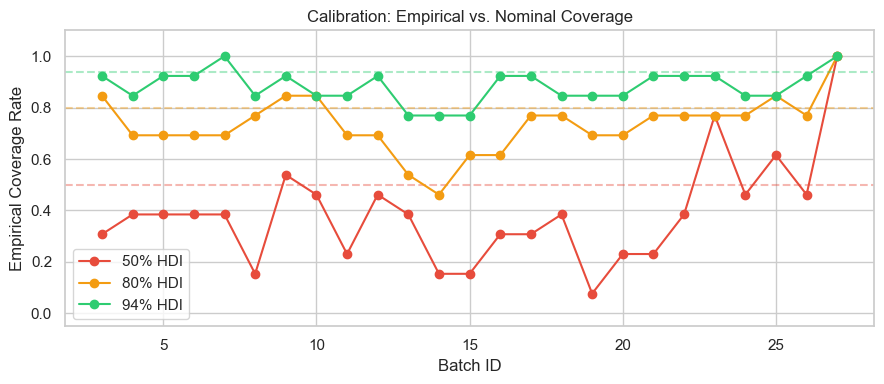

In [116]:
credible_levels = [0.50, 0.80, 0.94]
coverage_records = []

for batch_id in plot_batches:
    samples = get_forward_samples(batch_id)

    for level in credible_levels:
        hdi_bounds = az.hdi(samples, hdi_prob=level)
        lower = hdi_bounds[:, 0]
        upper = hdi_bounds[:, 1]

        for i, race in enumerate(all_races):
            y = official_dem_prop.loc[race]
            coverage_records.append({
                'Batch_ID': batch_id,
                'Race':     race,
                'Level':    level,
                'Covered':  bool(lower[i] <= y <= upper[i]),
                'Lower':    lower[i],
                'Upper':    upper[i],
            })

coverage_df = pd.DataFrame(coverage_records)

rate_df = (coverage_df
    .groupby(['Batch_ID', 'Level'])['Covered']
    .mean()
    .reset_index()
    .rename(columns={'Covered': 'Coverage_Rate'}))

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(9, 4))
colors = {0.50: '#e74c3c', 0.80: '#f39c12', 0.94: '#2ecc71'}

for level in credible_levels:
    sub = rate_df[rate_df['Level'] == level]
    ax.plot(sub['Batch_ID'], sub['Coverage_Rate'],
            marker='o', label=f'{int(level*100)}% HDI', color=colors[level])
    ax.axhline(level, linestyle='--', color=colors[level], alpha=0.4)

ax.set_xlabel('Batch ID')
ax.set_ylabel('Empirical Coverage Rate')
ax.set_title('Calibration: Empirical vs. Nominal Coverage')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()


## Diagnostic 2: Prediction Error Over Time

MAE and RMSE between the posterior mean and the official result, averaged across all 13 races, at each batch. Both should decrease monotonically as more data arrives.

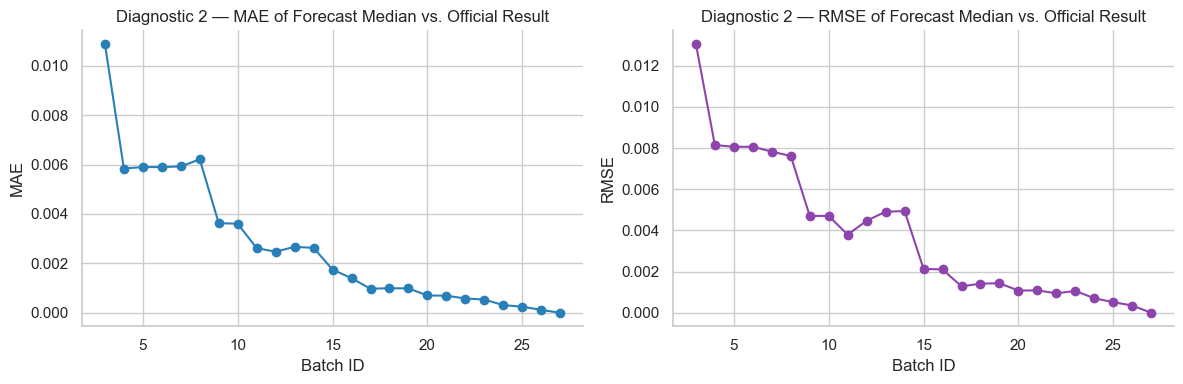

 Batch_ID    MAE   RMSE
        3 0.0109 0.0131
        4 0.0058 0.0081
        5 0.0059 0.0081
        6 0.0059 0.0081
        7 0.0059 0.0078
        8 0.0062 0.0076
        9 0.0036 0.0047
       10 0.0036 0.0047
       11 0.0026 0.0038
       12 0.0025 0.0045
       13 0.0027 0.0049
       14 0.0026 0.0049
       15 0.0018 0.0021
       16 0.0014 0.0021
       17 0.0010 0.0013
       18 0.0010 0.0014
       19 0.0010 0.0014
       20 0.0007 0.0011
       21 0.0007 0.0011
       22 0.0006 0.0009
       23 0.0005 0.0011
       24 0.0003 0.0007
       25 0.0002 0.0005
       26 0.0001 0.0004
       27 0.0000 0.0000


In [117]:
accuracy_records = []

for batch_id in plot_batches:
    samples = get_forward_samples(batch_id)
    median  = np.median(samples, axis=0)

    for i, race in enumerate(all_races):
        err = median[i] - official_dem_prop.loc[race]
        accuracy_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'Forecast': median[i],
            'Error':    err,
            'AbsError': abs(err),
            'SqError':  err ** 2,
        })

accuracy_df = pd.DataFrame(accuracy_records)

agg = accuracy_df.groupby('Batch_ID').agg(
    MAE  = ('AbsError', 'mean'),
    RMSE = ('SqError',  lambda x: np.sqrt(x.mean())),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, color in zip(axes,
                              ['MAE',     'RMSE'],
                              ['#2980b9', '#8e44ad']):
    ax.plot(agg['Batch_ID'], agg[metric], marker='o', color=color)
    ax.set_xlabel('Batch ID')
    ax.set_ylabel(metric)
    ax.set_title(f'Diagnostic 2 — {metric} of Forecast Median vs. Official Result')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(agg.round(4).to_string(index=False))


## Diagnostic 5: Interval Score

The interval score for a $(1-\alpha)$ interval $[L, U]$ is:

$$S = (U - L) + \frac{2}{\alpha}(L - y)_+ + \frac{2}{\alpha}(y - U)_+$$

Lower is better. The first term penalizes wide intervals (sharpness); the second and third penalize missing the truth. Decomposing into Width and Penalty reveals whether the score is driven by over-confidence or imprecision.

C:\Users\ricky\AppData\Local\Temp\ipykernel_15668\1682446764.py:7: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_bounds = az.hdi(samples, hdi_prob=LEVEL)


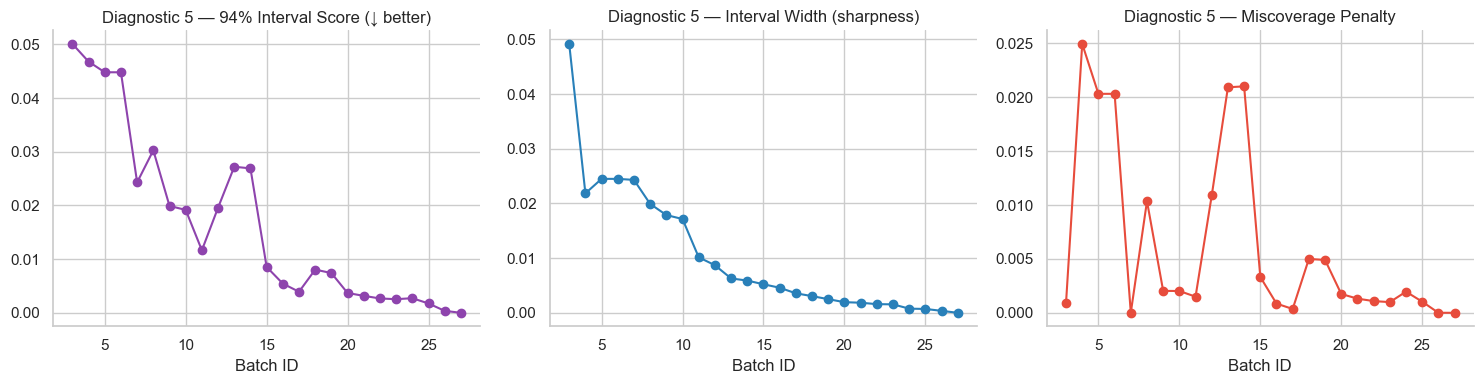

 Batch_ID  Mean_Score  Mean_Width  Mean_Penalty
        3      0.0501      0.0492        0.0009
        4      0.0468      0.0218        0.0250
        5      0.0448      0.0245        0.0203
        6      0.0448      0.0245        0.0203
        7      0.0243      0.0243        0.0000
        8      0.0303      0.0199        0.0104
        9      0.0199      0.0179        0.0020
       10      0.0192      0.0172        0.0020
       11      0.0117      0.0102        0.0015
       12      0.0196      0.0087        0.0109
       13      0.0272      0.0063        0.0209
       14      0.0269      0.0059        0.0210
       15      0.0085      0.0052        0.0033
       16      0.0054      0.0046        0.0009
       17      0.0039      0.0036        0.0004
       18      0.0081      0.0031        0.0050
       19      0.0074      0.0025        0.0049
       20      0.0037      0.0019        0.0017
       21      0.0032      0.0018        0.0013
       22      0.0027      0.0016       

In [118]:
LEVEL = 0.94
alpha = 1 - LEVEL
interval_records = []

for batch_id in plot_batches:
    samples    = get_forward_samples(batch_id)
    hdi_bounds = az.hdi(samples, hdi_prob=LEVEL)

    for i, race in enumerate(all_races):
        y    = official_dem_prop.loc[race]
        L, U = hdi_bounds[i, 0], hdi_bounds[i, 1]
        width   = U - L
        penalty = (2 / alpha) * max(0.0, L - y) + (2 / alpha) * max(0.0, y - U)
        interval_records.append({
            'Batch_ID': batch_id,
            'Race':     race,
            'Score':    width + penalty,
            'Width':    width,
            'Penalty':  penalty,
        })

interval_df = pd.DataFrame(interval_records)

agg_int = interval_df.groupby('Batch_ID').agg(
    Mean_Score   = ('Score',   'mean'),
    Mean_Width   = ('Width',   'mean'),
    Mean_Penalty = ('Penalty', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    ('Mean_Score',   f'{int(LEVEL*100)}% Interval Score (↓ better)', '#8e44ad'),
    ('Mean_Width',   'Interval Width (sharpness)',                    '#2980b9'),
    ('Mean_Penalty', 'Miscoverage Penalty',                           '#e74c3c'),
]
for ax, (col, title, color) in zip(axes, panels):
    ax.plot(agg_int['Batch_ID'], agg_int[col], marker='o', color=color)
    ax.set_xlabel('Batch ID')
    ax.set_title(f'Diagnostic 5 — {title}')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(agg_int.round(4).to_string(index=False))
